In [1]:
from diffusion_models.models import diffusion as dd
import diffusion_models.utils.common_logging as cl
import numpy as np
from diffusion_models.utils import common_utils as ut
import pandas as pd
import os
import pymc as pm
from pytensor import tensor as at

/home/rkm160630/anaconda3/envs/ds/lib/python3.10/site-packages/pymc/sampling/jax.py:39: UserWarning: This module is experimental.
  warnings.warn("This module is experimental.")


In [2]:
(0.2515518 + 2*0.0008319) * np.exp( ((0.2515518 + 2*0.0008319)**2) / (2*0.0008319) )

1.3802884675754678e+16

In [3]:
v, a, z, t_er, lp_v, X, RT = dd._test_likelihood_using_prior(100, 20)

2023-01-12 14:54:32,353 - diffusion - DEBUG - Starting Diffusion test


DEBUG:diffusion:Starting Diffusion test


2023-01-12 14:54:39,552 - diffusion - DEBUG - lp: [[0.00000000e+000 0.00000000e+000 1.32958504e+036 ... 1.41589908e+046
  0.00000000e+000 2.18776989e+048]
 [0.00000000e+000 7.95880207e-064 1.94152409e+014 ... 5.48754587e-039
  0.00000000e+000 0.00000000e+000]
 [8.40202236e-122 5.39967083e-074 1.48770251e-107 ... 1.53300308e-148
  1.05101931e-101 4.00646554e-102]
 ...
 [1.17239981e-016 7.80535064e-039 2.51279295e-015 ... 7.14439490e-042
  0.00000000e+000 1.22577362e-023]
 [2.86345790e+049 1.36891112e-017 1.11110854e-014 ... 0.00000000e+000
  0.00000000e+000 1.74620253e+058]
 [3.56029310e+045 4.16113278e-014 1.59588721e-018 ... 1.71290995e+041
  4.27850191e-022 4.41144024e-005]]


DEBUG:diffusion:lp: [[0.00000000e+000 0.00000000e+000 1.32958504e+036 ... 1.41589908e+046
  0.00000000e+000 2.18776989e+048]
 [0.00000000e+000 7.95880207e-064 1.94152409e+014 ... 5.48754587e-039
  0.00000000e+000 0.00000000e+000]
 [8.40202236e-122 5.39967083e-074 1.48770251e-107 ... 1.53300308e-148
  1.05101931e-101 4.00646554e-102]
 ...
 [1.17239981e-016 7.80535064e-039 2.51279295e-015 ... 7.14439490e-042
  0.00000000e+000 1.22577362e-023]
 [2.86345790e+049 1.36891112e-017 1.11110854e-014 ... 0.00000000e+000
  0.00000000e+000 1.74620253e+058]
 [3.56029310e+045 4.16113278e-014 1.59588721e-018 ... 1.71290995e+041
  4.27850191e-022 4.41144024e-005]]


2023-01-12 14:54:39,588 - diffusion - DEBUG - X:[[0 1 1 ... 1 1 1]
 [1 0 1 ... 0 1 1]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 1 0]
 [1 0 0 ... 0 1 1]
 [1 0 0 ... 1 0 0]]


DEBUG:diffusion:X:[[0 1 1 ... 1 1 1]
 [1 0 1 ... 0 1 1]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 1 0]
 [1 0 0 ... 0 1 1]
 [1 0 0 ... 1 0 0]]


2023-01-12 14:54:39,622 - diffusion - DEBUG - RT:[[2.78274906 0.59763595 3.64433615 ... 1.8935008  0.5433522  1.51234349]
 [3.18804638 2.18545478 3.7498518  ... 0.44676173 1.73031638 1.53884408]
 [2.58019031 0.36173437 1.91749783 ... 3.81711989 1.64780539 1.66553298]
 ...
 [0.30885981 2.33632435 0.18258093 ... 2.61391538 0.60949959 0.94364279]
 [3.50816759 2.88170054 2.61465696 ... 0.77426724 0.61658805 1.96960138]
 [2.36507616 0.88146732 1.22625078 ... 3.10559704 1.5075243  0.17655183]]


DEBUG:diffusion:RT:[[2.78274906 0.59763595 3.64433615 ... 1.8935008  0.5433522  1.51234349]
 [3.18804638 2.18545478 3.7498518  ... 0.44676173 1.73031638 1.53884408]
 [2.58019031 0.36173437 1.91749783 ... 3.81711989 1.64780539 1.66553298]
 ...
 [0.30885981 2.33632435 0.18258093 ... 2.61391538 0.60949959 0.94364279]
 [3.50816759 2.88170054 2.61465696 ... 0.77426724 0.61658805 1.96960138]
 [2.36507616 0.88146732 1.22625078 ... 3.10559704 1.5075243  0.17655183]]


2023-01-12 14:54:39,624 - diffusion - INFO - Test Successful!


INFO:diffusion:Test Successful!


In [4]:
lp_v.shape

(100, 20)

In [5]:
df = pd.DataFrame({"lp":lp_v.flatten(), "RT":RT.flatten()})
df

,lp,RT
0,0.000000e+00,2.782749
1,0.000000e+00,0.597636
2,1.329585e+36,3.644336
3,0.000000e+00,0.211856
4,0.000000e+00,1.314514
...,...,...
1995,4.252191e-52,3.847731
1996,3.303106e+48,1.845046
1997,1.712910e+41,3.105597
1998,4.278502e-22,1.507524


<AxesSubplot: xlabel='RT', ylabel='lp'>

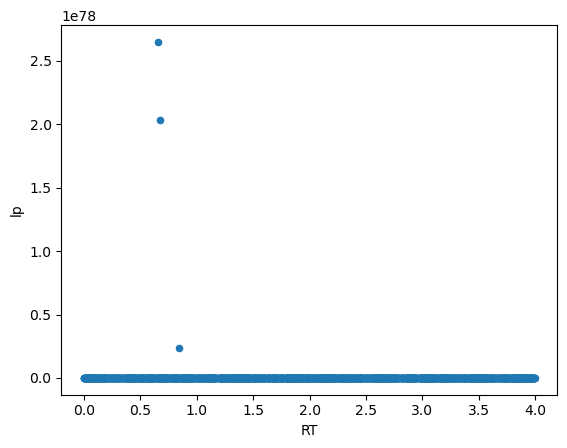

In [6]:
df.plot(x="RT", y="lp", kind="scatter")

<AxesSubplot: >

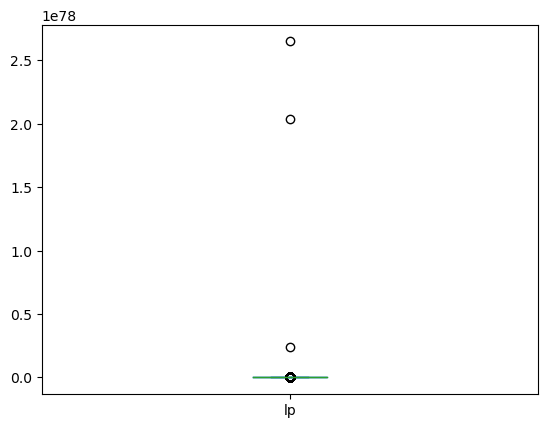

In [7]:
df.loc[:,"lp"].plot(kind="box")

In [8]:
np.save("v.npy",v)
np.save("a.npy",a)
np.save("z.npy",z)
np.save("t_er.npy",t_er)
np.save("X.npy",X)
np.save("RT.npy",RT)

In [9]:
#prior_chain = dd.sample_prior_data(10,2,9)

In [10]:
#post_chain = dd.sample_posterior_params(RT, X, 10,2,10)
